In [141]:
#importing required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle
from sklearn.preprocessing import LabelEncoder

print('------------')
print('### Python version: ' + __import__('sys').version)
print('### NumPy version: ' + np.__version__)
print('------------')

------------
### Python version: 3.10.12 (main, Nov 20 2023, 15:14:05) [GCC 11.4.0]
### NumPy version: 1.25.2
------------


In [142]:
df = pd.read_csv('/content/sample_data/Motor_Vehicle_Collisions.csv', low_memory=False)

In [143]:
df.head()

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,09/11/2021,2:39,NaN,NaN,NaN,NaN,NaN,WHITESTONE EXPRESSWAY,20 AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4455765.0,Sedan,Sedan,NaN,NaN,NaN
1,03/26/2022,11:45,NaN,NaN,NaN,NaN,NaN,QUEENSBORO BRIDGE UPPER,NaN,NaN,...,NaN,NaN,NaN,NaN,4513547.0,Sedan,NaN,NaN,NaN,NaN
2,06/29/2022,6:55,NaN,NaN,NaN,NaN,NaN,THROGS NECK BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4541903.0,Sedan,Pick-up Truck,NaN,NaN,NaN
3,09/11/2021,9:35,BROOKLYN,11208.0,40.667202,-73.866500,"(40.667202, -73.8665)",NaN,NaN,1211 LORING AVENUE,...,NaN,NaN,NaN,NaN,4456314.0,Sedan,NaN,NaN,NaN,NaN
4,12/14/2021,8:13,BROOKLYN,11233.0,40.683304,-73.917274,"(40.683304, -73.917274)",SARATOGA AVENUE,DECATUR STREET,NaN,...,NaN,NaN,NaN,NaN,4486609.0,NaN,NaN,NaN,NaN,NaN


In [144]:
df.shape

(11110, 29)

In [145]:
df.dtypes

CRASH DATE                        object
CRASH TIME                        object
BOROUGH                           object
ZIP CODE                         float64
LATITUDE                         float64
LONGITUDE                        float64
LOCATION                          object
ON STREET NAME                    object
CROSS STREET NAME                 object
OFF STREET NAME                   object
NUMBER OF PERSONS INJURED          int64
NUMBER OF PERSONS KILLED           int64
NUMBER OF PEDESTRIANS INJURED      int64
NUMBER OF PEDESTRIANS KILLED       int64
NUMBER OF CYCLIST INJURED        float64
NUMBER OF CYCLIST KILLED         float64
NUMBER OF MOTORIST INJURED       float64
NUMBER OF MOTORIST KILLED        float64
CONTRIBUTING FACTOR VEHICLE 1     object
CONTRIBUTING FACTOR VEHICLE 2     object
CONTRIBUTING FACTOR VEHICLE 3     object
CONTRIBUTING FACTOR VEHICLE 4     object
CONTRIBUTING FACTOR VEHICLE 5     object
COLLISION_ID                     float64
VEHICLE TYPE COD

In [146]:
df.isna().sum()

CRASH DATE                           0
CRASH TIME                           0
BOROUGH                           3849
ZIP CODE                          3852
LATITUDE                           923
LONGITUDE                          923
LOCATION                           923
ON STREET NAME                    2954
CROSS STREET NAME                 5952
OFF STREET NAME                   8156
NUMBER OF PERSONS INJURED            0
NUMBER OF PERSONS KILLED             0
NUMBER OF PEDESTRIANS INJURED        0
NUMBER OF PEDESTRIANS KILLED         0
NUMBER OF CYCLIST INJURED            1
NUMBER OF CYCLIST KILLED             1
NUMBER OF MOTORIST INJURED           1
NUMBER OF MOTORIST KILLED            1
CONTRIBUTING FACTOR VEHICLE 1       50
CONTRIBUTING FACTOR VEHICLE 2     2458
CONTRIBUTING FACTOR VEHICLE 3     9932
CONTRIBUTING FACTOR VEHICLE 4    10806
CONTRIBUTING FACTOR VEHICLE 5    11022
COLLISION_ID                         1
VEHICLE TYPE CODE 1                122
VEHICLE TYPE CODE 2      

In [147]:
columns_to_remove = [
    'CONTRIBUTING FACTOR VEHICLE 2',
    'CONTRIBUTING FACTOR VEHICLE 3',
    'CONTRIBUTING FACTOR VEHICLE 4',
    'CONTRIBUTING FACTOR VEHICLE 5',
    'OFF STREET NAME',
    'LOCATION',
    'VEHICLE TYPE CODE 2',
    'VEHICLE TYPE CODE 3',
    'VEHICLE TYPE CODE 4',
    'VEHICLE TYPE CODE 5',
    'LATITUDE',
    'LONGITUDE',
    'CROSS STREET NAME',
    'COLLISION_ID'
]
df = df.drop(columns_to_remove, axis=1, errors='ignore')

In [148]:
df.isna().sum()

CRASH DATE                          0
CRASH TIME                          0
BOROUGH                          3849
ZIP CODE                         3852
ON STREET NAME                   2954
NUMBER OF PERSONS INJURED           0
NUMBER OF PERSONS KILLED            0
NUMBER OF PEDESTRIANS INJURED       0
NUMBER OF PEDESTRIANS KILLED        0
NUMBER OF CYCLIST INJURED           1
NUMBER OF CYCLIST KILLED            1
NUMBER OF MOTORIST INJURED          1
NUMBER OF MOTORIST KILLED           1
CONTRIBUTING FACTOR VEHICLE 1      50
VEHICLE TYPE CODE 1               122
dtype: int64

In [149]:
df['CRASH DATETIME'] = pd.to_datetime(df['CRASH DATE'] + ' ' + df['CRASH TIME'])

df.drop(['CRASH DATE'], axis=1, inplace=True)
df['CONTRIBUTING FACTOR VEHICLE 1'] = df['CONTRIBUTING FACTOR VEHICLE 1'].astype('object')
df['VEHICLE TYPE CODE 1'] = df['VEHICLE TYPE CODE 1'].astype('object')

df['ZIP CODE'] = pd.to_numeric(df['ZIP CODE'], errors='coerce').fillna(-1).astype(int)

In [150]:
df.dtypes

CRASH TIME                               object
BOROUGH                                  object
ZIP CODE                                  int64
ON STREET NAME                           object
NUMBER OF PERSONS INJURED                 int64
NUMBER OF PERSONS KILLED                  int64
NUMBER OF PEDESTRIANS INJURED             int64
NUMBER OF PEDESTRIANS KILLED              int64
NUMBER OF CYCLIST INJURED               float64
NUMBER OF CYCLIST KILLED                float64
NUMBER OF MOTORIST INJURED              float64
NUMBER OF MOTORIST KILLED               float64
CONTRIBUTING FACTOR VEHICLE 1            object
VEHICLE TYPE CODE 1                      object
CRASH DATETIME                   datetime64[ns]
dtype: object

In [151]:
df = df.dropna(subset=['NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED'])


categorical_columns = ['BOROUGH', 'ZIP CODE', 'ON STREET NAME', 'CONTRIBUTING FACTOR VEHICLE 1', 'VEHICLE TYPE CODE 1']
for column in categorical_columns:
    df[column].fillna(df[column].mode()[0], inplace=True)  # mode()

In [152]:
df.isna().sum()
df.shape

(11110, 15)

In [153]:
# Drop duplicates
df = df.drop_duplicates()
duplicates_after = df[df.duplicated()]
num_duplicates_after = duplicates_after.shape[0]
print("Number of duplicate rows after dropping:", num_duplicates_after)


Number of duplicate rows after dropping: 0


In [154]:
#convert to lowercase

df['CONTRIBUTING FACTOR VEHICLE 1'] = df['CONTRIBUTING FACTOR VEHICLE 1'].str.lower()

df['VEHICLE TYPE CODE 1'] = df['VEHICLE TYPE CODE 1'].str.lower()
df['BOROUGH'] = df['BOROUGH'].str.lower()
df['ON STREET NAME'] = df['ON STREET NAME'].str.lower()
df['CONTRIBUTING FACTOR VEHICLE 1'].str.count('unspecified').sum()


2798

In [155]:
df.nunique()

CRASH TIME                       1336
BOROUGH                             5
ZIP CODE                          181
ON STREET NAME                   1910
NUMBER OF PERSONS INJURED          10
NUMBER OF PERSONS KILLED            3
NUMBER OF PEDESTRIANS INJURED       4
NUMBER OF PEDESTRIANS KILLED        2
NUMBER OF CYCLIST INJURED           3
NUMBER OF CYCLIST KILLED            2
NUMBER OF MOTORIST INJURED         10
NUMBER OF MOTORIST KILLED           3
CONTRIBUTING FACTOR VEHICLE 1      49
VEHICLE TYPE CODE 1                87
CRASH DATETIME                   8567
dtype: int64

In [156]:
columns_of_interest = [
    'NUMBER OF PERSONS INJURED',
    'NUMBER OF PERSONS KILLED',
    'NUMBER OF PEDESTRIANS INJURED',
    'NUMBER OF PEDESTRIANS KILLED',
    'NUMBER OF CYCLIST INJURED',
    'NUMBER OF MOTORIST INJURED',
    'NUMBER OF MOTORIST KILLED'
]

# Printing unique values and their counts for each column
for column_name in columns_of_interest:
    value_counts = df[column_name].value_counts()
    print(f"Unique Values and Counts for Column: {column_name}")
    for value, count in value_counts.items():
        print(f"{value}: {count}")

Unique Values and Counts for Column: NUMBER OF PERSONS INJURED
0: 7198
1: 2996
2: 619
3: 172
4: 70
5: 26
6: 14
7: 6
9: 5
18: 1
Unique Values and Counts for Column: NUMBER OF PERSONS KILLED
0: 11069
1: 37
2: 1
Unique Values and Counts for Column: NUMBER OF PEDESTRIANS INJURED
0: 10376
1: 704
2: 26
3: 1
Unique Values and Counts for Column: NUMBER OF PEDESTRIANS KILLED
0: 11091
1: 16
Unique Values and Counts for Column: NUMBER OF CYCLIST INJURED
0.0: 10585
1.0: 513
2.0: 8
Unique Values and Counts for Column: NUMBER OF MOTORIST INJURED
0.0: 8568
1.0: 1691
2.0: 560
3.0: 165
4.0: 70
5.0: 27
6.0: 13
7.0: 7
9.0: 4
18.0: 1
Unique Values and Counts for Column: NUMBER OF MOTORIST KILLED
0.0: 11088
1.0: 17
2.0: 1


In [157]:
# Group rare categories into 'Other'
threshold = 10
top_categories = df['VEHICLE TYPE CODE 1'].value_counts().index[:threshold]
df['VEHICLE TYPE CODE 1'] = df['VEHICLE TYPE CODE 1'].apply(lambda x: x if x in top_categories else 'Other')


In [158]:
threshold = 22
top_categories = df['CONTRIBUTING FACTOR VEHICLE 1'].value_counts().index[:threshold]
df['CONTRIBUTING FACTOR VEHICLE 1'] = df['CONTRIBUTING FACTOR VEHICLE 1'].apply(lambda x: x if x in top_categories else 'Other')


In [159]:
column_name = 'CONTRIBUTING FACTOR VEHICLE 1'

value_counts = df[column_name].value_counts()
print("Unique Values and Counts for Column:", column_name)
for value, count in value_counts.items():
    print(f"{value}: {count}")

Unique Values and Counts for Column: CONTRIBUTING FACTOR VEHICLE 1
unspecified: 2798
driver inattention/distraction: 2674
following too closely: 758
failure to yield right-of-way: 741
passing or lane usage improper: 519
passing too closely: 445
unsafe speed: 417
traffic control disregarded: 343
backing unsafely: 337
other vehicular: 332
Other: 265
turning improperly: 261
driver inexperience: 225
unsafe lane changing: 217
alcohol involvement: 185
reaction to uninvolved vehicle: 150
pedestrian/bicyclist/other pedestrian error/confusion: 107
view obstructed/limited: 89
aggressive driving/road rage: 64
oversized vehicle: 54
fell asleep: 50
pavement slippery: 39
brakes defective: 37


In [160]:
df['CONTRIBUTING FACTOR VEHICLE 1'] = df['CONTRIBUTING FACTOR VEHICLE 1'].replace('unspecified', 'risky behavior')
column_name = 'VEHICLE TYPE CODE 1'

value_counts = df[column_name].value_counts()

print("Unique Values and Counts for Column:", column_name)
for value, count in value_counts.items():
    print(f"{value}: {count}")

Unique Values and Counts for Column: VEHICLE TYPE CODE 1
sedan: 5427
station wagon/sport utility vehicle: 3834
Other: 500
taxi: 308
pick-up truck: 234
bus: 200
box truck: 180
bike: 160
ambulance: 90
motorcycle: 88
e-bike: 86


In [161]:
def detect_outliers(df, columns):
    outlier_indices = []

    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        outlier_step = 1.5 * IQR
        outlier_list_col = df[(df[column] < Q1 - outlier_step) | (df[column] > Q3 + outlier_step)].index
        outlier_indices.extend(outlier_list_col)

    outlier_indices = list(set(outlier_indices))
    return outlier_indices

numerical_columns = [
    'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED',
    'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF PEDESTRIANS KILLED',
    'NUMBER OF CYCLIST INJURED', 'NUMBER OF CYCLIST KILLED',
    'NUMBER OF MOTORIST INJURED', 'NUMBER OF MOTORIST KILLED'
]

outliers = detect_outliers(df, numerical_columns)
print("Outliers detected in the data:")
print(df.loc[outliers])
df_no_outliers = df.drop(outliers)


Outliers detected in the data:
     CRASH TIME        BOROUGH  ZIP CODE           ON STREET NAME  \
0          2:39       brooklyn        -1    whitestone expressway   
1         11:45       brooklyn        -1  queensboro bridge upper   
8193       2:33       brooklyn     11206          flushing avenue   
8196       0:00       brooklyn        -1          riverside drive   
8197      17:58       brooklyn        -1              troy avenue   
...         ...            ...       ...                      ...   
8178      18:16         queens     11361                35 avenue   
8183      14:30  staten island     10306          hylan boulevard   
8184      15:30       brooklyn     11207         riverdale avenue   
8187      10:00       brooklyn     11204                19 avenue   
8189      20:20       brooklyn     11236           east 85 street   

      NUMBER OF PERSONS INJURED  NUMBER OF PERSONS KILLED  \
0                             2                         0   
1                 

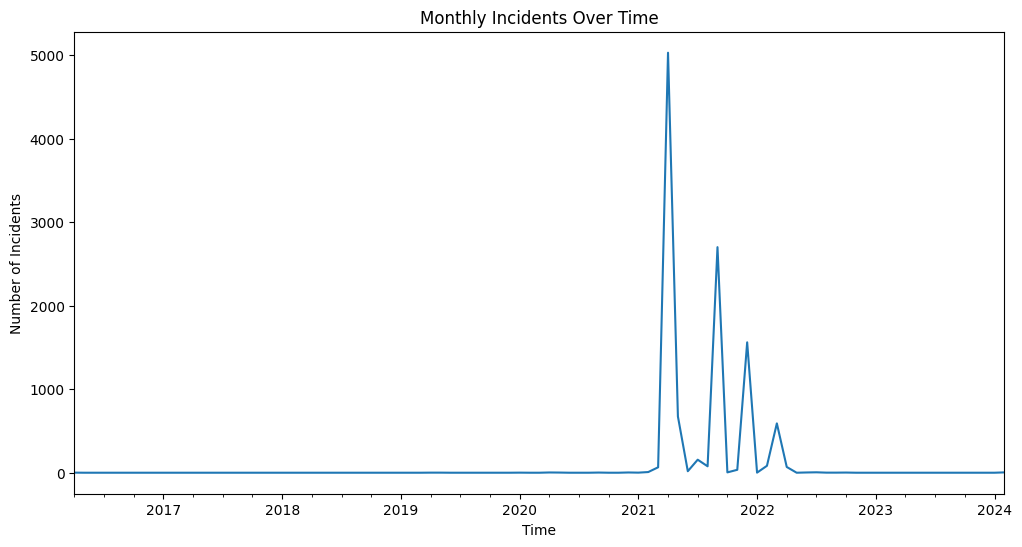

In [162]:

df['WEEKEND'] = (df['CRASH DATETIME'].dt.dayofweek >= 5).astype(int)
# Time Series Line Chart for Incidents Over Time
plt.figure(figsize=(12, 6))
df['CRASH DATETIME'] = pd.to_datetime(df['CRASH DATETIME'])
df.resample('M', on='CRASH DATETIME').size().plot()
plt.title('Monthly Incidents Over Time')
plt.xlabel('Time')
plt.ylabel('Number of Incidents')
plt.show()

In [163]:
df['NUMBER OF PERSONS KILLED'] = (df['NUMBER OF PERSONS KILLED'] > 0).astype(int)
df['NUMBER OF PERSONS INJURED'] = (df['NUMBER OF PERSONS INJURED'] > 0).astype(int)

df['NUMBER OF MOTORIST INJURED'] = (df['NUMBER OF MOTORIST INJURED'] > 0).astype(int)
df['NUMBER OF PEDESTRIANS INJURED'] = (df['NUMBER OF PEDESTRIANS INJURED'] > 0).astype(int)

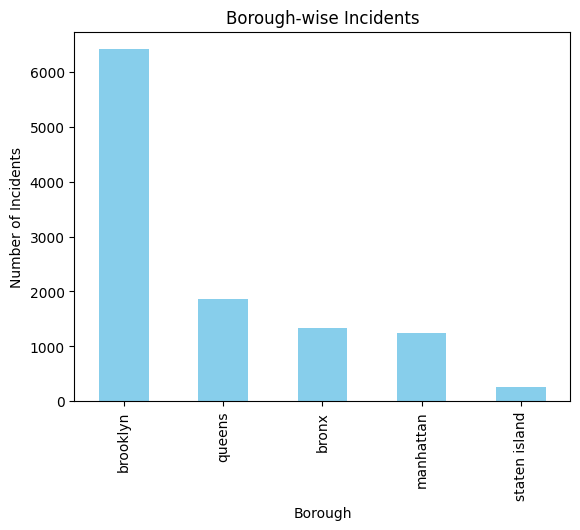

In [164]:
# Bar Chart for Borough-wise Incidents
borough_counts = df['BOROUGH'].value_counts()
borough_counts.plot(kind='bar', color='skyblue')
plt.title('Borough-wise Incidents')
plt.xlabel('Borough')
plt.ylabel('Number of Incidents')
plt.show()

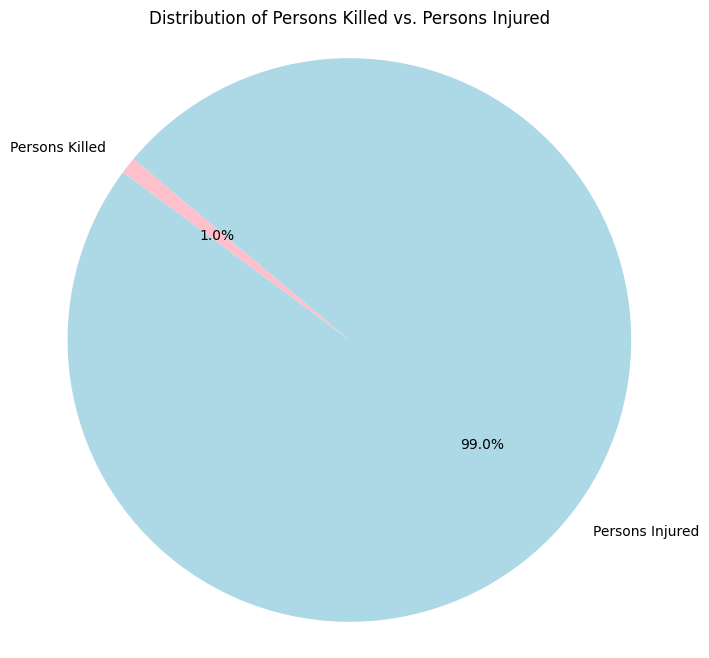

In [165]:
# contributing_factor_counts = df['CONTRIBUTING FACTOR VEHICLE 1'].value_counts().head(10)
total_killed = df['NUMBER OF PERSONS KILLED'].sum()
total_injured = df['NUMBER OF PERSONS INJURED'].sum()

labels = ['Persons Killed', 'Persons Injured']
sizes = [total_killed, total_injured]
colors = ['pink', 'lightblue']

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Persons Killed vs. Persons Injured')
plt.axis('equal')

plt.show()

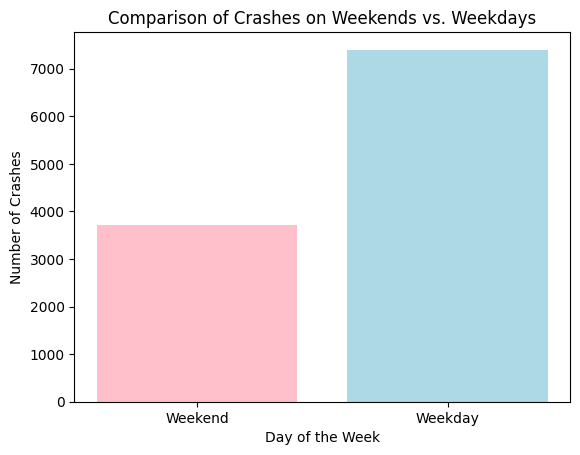

In [166]:
weekend_crashes = df[df['WEEKEND'] == 1].shape[0]
weekday_crashes = df[df['WEEKEND'] == 0].shape[0]

categories = ['Weekend', 'Weekday']
crash_counts = [weekend_crashes, weekday_crashes]

plt.bar(categories, crash_counts, color=['pink', 'lightblue'])
plt.xlabel('Day of the Week')
plt.ylabel('Number of Crashes')
plt.title('Comparison of Crashes on Weekends vs. Weekdays')
plt.show()

In [167]:
class_counts = df['NUMBER OF PEDESTRIANS INJURED'].value_counts()
print(class_counts)

NUMBER OF PEDESTRIANS INJURED
0    10376
1      731
Name: count, dtype: int64


In [168]:
print(df.columns)

Index(['CRASH TIME', 'BOROUGH', 'ZIP CODE', 'ON STREET NAME',
       'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED',
       'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF PEDESTRIANS KILLED',
       'NUMBER OF CYCLIST INJURED', 'NUMBER OF CYCLIST KILLED',
       'NUMBER OF MOTORIST INJURED', 'NUMBER OF MOTORIST KILLED',
       'CONTRIBUTING FACTOR VEHICLE 1', 'VEHICLE TYPE CODE 1',
       'CRASH DATETIME', 'WEEKEND'],
      dtype='object')


In [169]:
from imblearn.under_sampling import RandomUnderSampler

X = df.drop(columns=['NUMBER OF PEDESTRIANS INJURED'])
y = df['NUMBER OF PEDESTRIANS INJURED']

undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

X_resampled, y_resampled = undersampler.fit_resample(X, y)

resampled_data = pd.DataFrame(X_resampled, columns=X.columns)
resampled_data['NUMBER OF PEDESTRIANS INJURED'] = y_resampled

df = resampled_data.copy()
print(df['NUMBER OF PEDESTRIANS INJURED'].value_counts())

NUMBER OF PEDESTRIANS INJURED
0    731
1    731
Name: count, dtype: int64


In [170]:
print(X_resampled.shape, y_resampled.shape)

(1462, 15) (1462,)


In [171]:
df['CONTRIBUTING FACTOR VEHICLE 1'].unique()
df['VEHICLE TYPE CODE 1'].unique()
df['BOROUGH'].unique()
df['NUMBER OF CYCLIST INJURED'].unique()
df = df.drop('CRASH TIME', axis=1)

In [172]:
import os
import pickle
from sklearn.preprocessing import LabelEncoder
categorical_columns = ['BOROUGH', 'ON STREET NAME', 'CONTRIBUTING FACTOR VEHICLE 1', 'VEHICLE TYPE CODE 1']
encoders = {}

# Ensure the directory for storing the models exists
if not os.path.exists('models'):
    os.makedirs('models')

for col in categorical_columns:
    df[col] = df[col].astype(str)
    encoders[col] = LabelEncoder()
    df[col] = encoders[col].fit_transform(df[col])

    # Save each encoder to a .pkl file
    with open(f'models/{col}_encoder.pkl', 'wb') as file:
        pickle.dump(encoders[col], file)

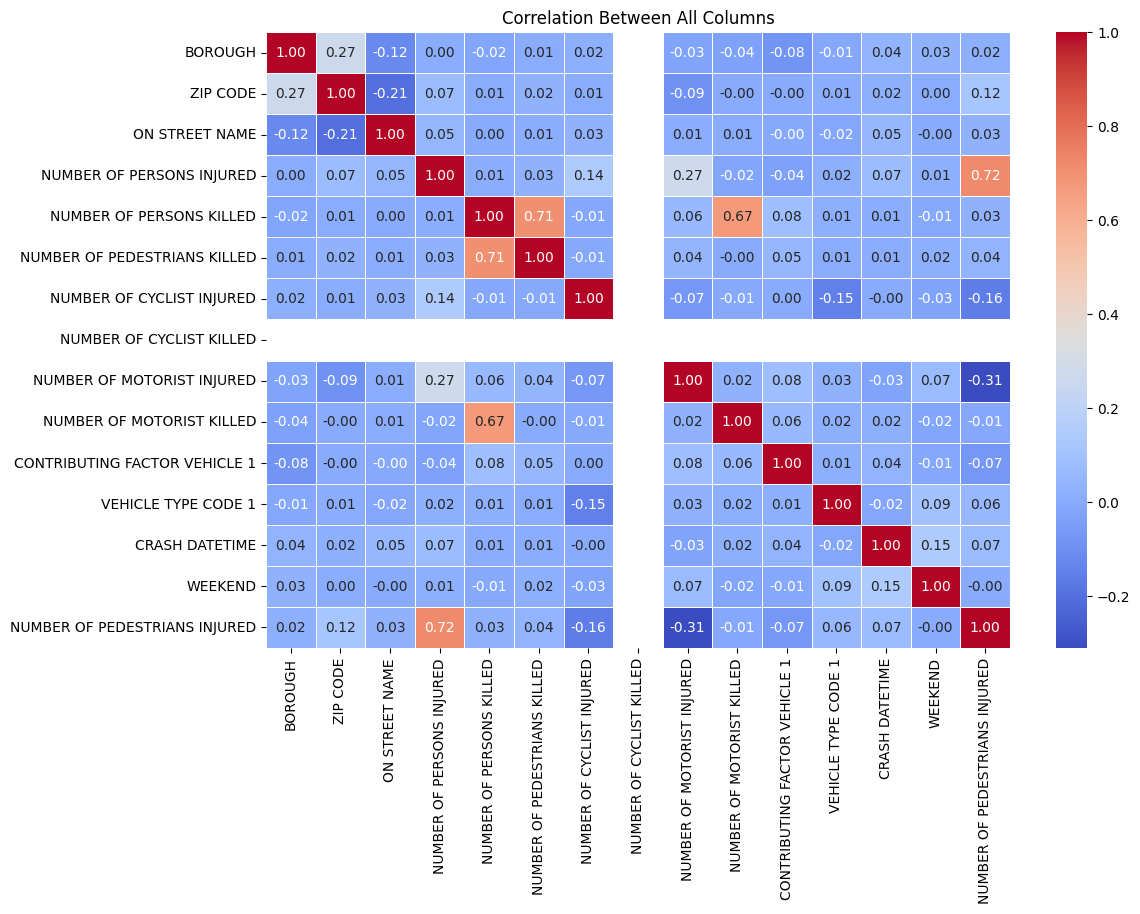

In [173]:
correlation_matrix = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Between All Columns')
plt.show()

In [174]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
df_new = df.copy()
X = df_new.drop([
    'NUMBER OF PEDESTRIANS INJURED',
    'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED',
    'NUMBER OF PEDESTRIANS KILLED',
    'NUMBER OF CYCLIST KILLED',
    'NUMBER OF MOTORIST KILLED'
], axis=1)
y = df['NUMBER OF PEDESTRIANS INJURED']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [175]:
df.columns

Index(['BOROUGH', 'ZIP CODE', 'ON STREET NAME', 'NUMBER OF PERSONS INJURED',
       'NUMBER OF PERSONS KILLED', 'NUMBER OF PEDESTRIANS KILLED',
       'NUMBER OF CYCLIST INJURED', 'NUMBER OF CYCLIST KILLED',
       'NUMBER OF MOTORIST INJURED', 'NUMBER OF MOTORIST KILLED',
       'CONTRIBUTING FACTOR VEHICLE 1', 'VEHICLE TYPE CODE 1',
       'CRASH DATETIME', 'WEEKEND', 'NUMBER OF PEDESTRIANS INJURED'],
      dtype='object')

In [176]:
print("Shapes of the datasets:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Shapes of the datasets:
X_train shape: (1169, 9)
y_train shape: (1169,)
X_test shape: (293, 9)
y_test shape: (293,)


In [177]:
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())]), numerical_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
    ]
)


In [178]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Setup the models
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
xgb_model = XGBClassifier(random_state=42)

# Define the pipelines
decision_tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', dt_model)
])

random_forest_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', rf_model)
])

xgboost_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb_model)
])

decision_tree_pipeline.fit(X_train, y_train)
y_pred_dt = decision_tree_pipeline.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_f1_score = f1_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
print(f"Decision Tree accuracy: {dt_accuracy * 100:.2f}%")
print(f"Decision Tree F1 Score: {dt_f1_score:.2f}")
print(f"Decision Tree Precision: {dt_precision:.2f}")
print(f"Decision Tree Recall: {dt_recall:.2f}")

# Train and evaluate the Random Forest model
random_forest_pipeline.fit(X_train, y_train)
y_pred_rf = random_forest_pipeline.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1_score = f1_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
print(f"Random Forest accuracy: {rf_accuracy * 100:.2f}%")
print(f"Random Forest F1 Score: {rf_f1_score:.2f}")
print(f"Random Forest Precision: {rf_precision:.2f}")
print(f"Random Forest Recall: {rf_recall:.2f}")

# Train and evaluate the XGBoost model
xgboost_pipeline.fit(X_train, y_train)
y_pred_xgb = xgboost_pipeline.predict(X_test)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_f1_score = f1_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
print(f"XGBoost accuracy: {xgb_accuracy * 100:.2f}%")
print(f"XGBoost F1 score: {xgb_f1_score:.2f}")
print(f"XGBoost Precision: {xgb_precision:.2f}")
print(f"XGBoost Recall: {xgb_recall:.2f}")


Decision Tree accuracy: 63.48%
Decision Tree F1 Score: 0.64
Decision Tree Precision: 0.62
Decision Tree Recall: 0.66
Random Forest accuracy: 69.62%
Random Forest F1 Score: 0.70
Random Forest Precision: 0.68
Random Forest Recall: 0.72
XGBoost accuracy: 69.62%
XGBoost F1 score: 0.72
XGBoost Precision: 0.66
XGBoost Recall: 0.78


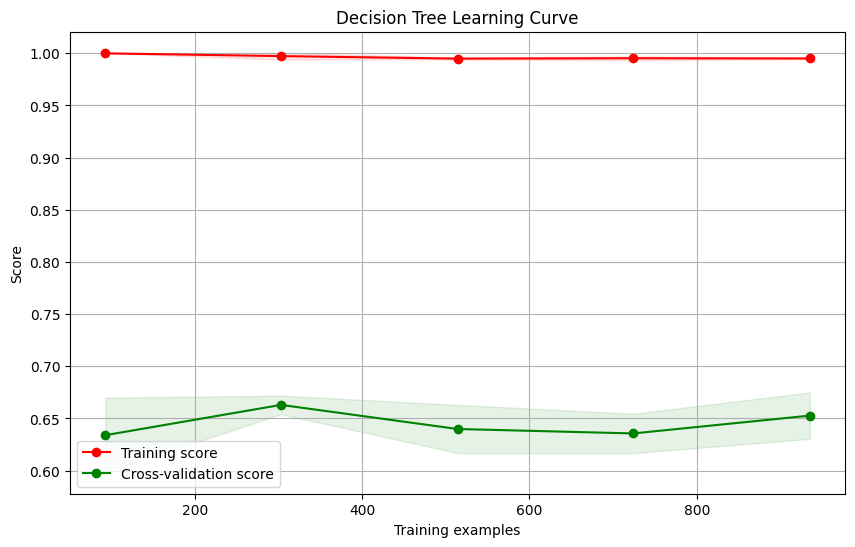

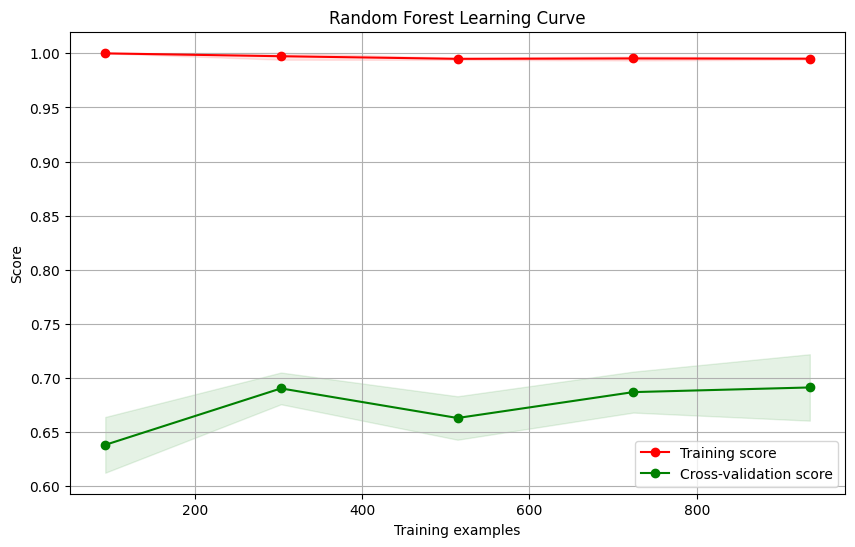

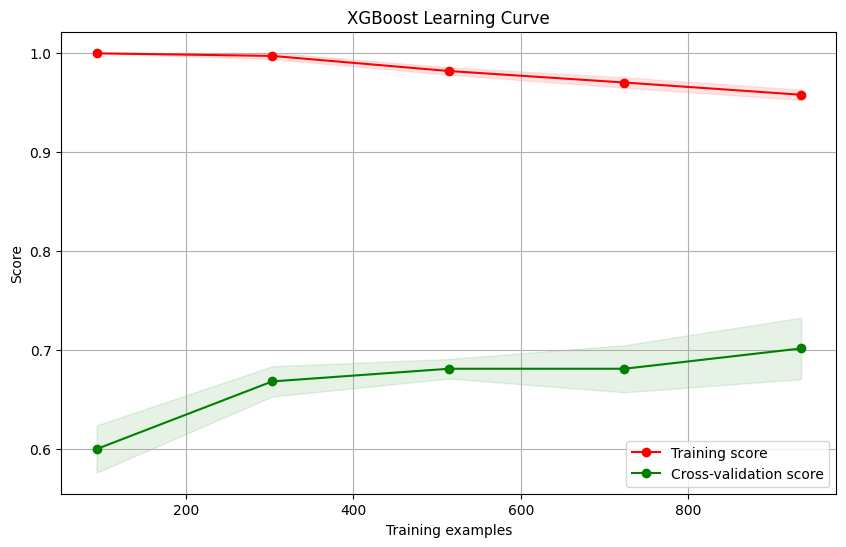

In [179]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

# Data preparation
df_new = df.copy()
X = df_new.drop([
    'NUMBER OF PEDESTRIANS INJURED',
    'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED',
    'NUMBER OF PEDESTRIANS KILLED',
    'NUMBER OF CYCLIST KILLED',
    'NUMBER OF MOTORIST KILLED'
], axis=1)
y = df['NUMBER OF PEDESTRIANS INJURED']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Defining numerical and categorical features
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

# Preprocessor setup
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), numerical_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features)
    ]
)

# Model setup
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
xgb_model = XGBClassifier(random_state=42)

# Pipelines
decision_tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', dt_model)
])

random_forest_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', rf_model)
])

xgboost_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb_model)
])

# Function to plot learning curves
def plot_learning_curve(estimator, title, X, y, cv=None, n_jobs=None, train_sizes=np.linspace(0.1, 1.0, 5)):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring='accuracy')
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.grid(True)
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, color="r", alpha=0.1)
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, color="g", alpha=0.1)
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.legend(loc="best")
    plt.show()

# Plotting learning curves for each model
plot_learning_curve(decision_tree_pipeline, "Decision Tree Learning Curve", X_train, y_train, cv=5, n_jobs=4)
plot_learning_curve(random_forest_pipeline, "Random Forest Learning Curve", X_train, y_train, cv=5, n_jobs=4)
plot_learning_curve(xgboost_pipeline, "XGBoost Learning Curve", X_train, y_train, cv=5, n_jobs=4)


In [180]:
dt_model = DecisionTreeClassifier(max_depth=10, min_samples_split=20, min_samples_leaf=10, max_features='sqrt')
decision_tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',dt_model)
])

# Train the Decision Tree model
decision_tree_pipeline.fit(X_train, y_train)
y_pred_dt = decision_tree_pipeline.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_f1_score = f1_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
print(f"Decision Tree accuracy: {dt_accuracy * 100:.2f}%")
print(f"Decision Tree F1 Score: {dt_f1_score:.2f}")
print(f"Decision Tree Precision: {dt_precision:.2f}")
print(f"Decision Tree Recall: {dt_recall:.2f}")

Decision Tree accuracy: 67.24%
Decision Tree F1 Score: 0.71
Decision Tree Precision: 0.63
Decision Tree Recall: 0.81


In [181]:

rf_model = RandomForestClassifier(n_estimators=500,  max_depth=15, min_samples_split=10, min_samples_leaf=4, max_features='sqrt', max_leaf_nodes=None, bootstrap=True, random_state=42)
random_forest_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf_model)
])

random_forest_pipeline.fit(X_train, y_train)
y_pred_rf = random_forest_pipeline.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1_score = f1_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
print(f"Random Forest accuracy: {rf_accuracy * 100:.2f}%")
print(f"Random Forest F1 Score: {rf_f1_score:.2f}")
print(f"Random Forest Precision: {rf_precision:.2f}")
print(f"Random Forest Recall: {rf_recall:.2f}")

Random Forest accuracy: 72.70%
Random Forest F1 Score: 0.75
Random Forest Precision: 0.68
Random Forest Recall: 0.84


In [182]:
from sklearn.metrics import accuracy_score, f1_score
warnings.filterwarnings('ignore')

xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_estimators=200, max_depth=20, learning_rate=0.0015, subsample=0.8, colsample_bytree=0.8, random_state=42)
xgboost_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb_model)
])

xgboost_pipeline.fit(X_train, y_train)
y_pred_xgb = xgboost_pipeline.predict(X_test)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_f1_score = f1_score(y_test,  y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
print(f"XGBoost accuracy: {xgb_accuracy * 100:.2f}%")
print(f"XGBoost F1 score: {xgb_f1_score:.2f}")
print(f"XGBoost Precision: {xgb_precision:.2f}")
print(f"XGBoost Recall: {xgb_recall:.2f}")

XGBoost accuracy: 70.65%
XGBoost F1 score: 0.73
XGBoost Precision: 0.67
XGBoost Recall: 0.80


In [183]:
from sklearn.model_selection import GridSearchCV

# Parameter grid for Decision Tree
dt_param_grid = {
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 10, 20],
    'classifier__min_samples_leaf': [1, 5, 10]
}

# Parameter grid for Random Forest
rf_param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 10, 20],
    'classifier__min_samples_leaf': [1, 5, 10],
    'classifier__max_features': ['auto', 'sqrt']
}

# Parameter grid for XGBoost
xgb_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [5, 10, 15],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__subsample': [0.5, 0.8, 1.0],
    'classifier__colsample_bytree': [0.5, 0.8, 0.9]
}



In [184]:
dt_grid_search = GridSearchCV(decision_tree_pipeline, dt_param_grid, cv=5, scoring='f1', verbose=1)
dt_grid_search.fit(X_train, y_train)

# Evaluate on test set
dt_best_model = dt_grid_search.best_estimator_
y_pred_dt = dt_best_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_f1_score = f1_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
print("Best parameters for Decision Tree:", dt_grid_search.best_params_)
print(f"Decision Tree Test Accuracy: {dt_accuracy * 100:.2f}%")
print(f"Decision Tree Test F1 Score: {dt_f1_score:.2f}")
print(f"Decision Tree Precision: {dt_precision:.2f}")
print(f"Decision Tree Recall: {dt_recall:.2f}")

# Grid search for Random Forest
rf_grid_search = GridSearchCV(random_forest_pipeline, rf_param_grid, cv=5, scoring='f1', verbose=1)
rf_grid_search.fit(X_train, y_train)

# Evaluate on test set
rf_best_model = rf_grid_search.best_estimator_
y_pred_rf = rf_best_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1_score = f1_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)

print("Best parameters for Random Forest:", rf_grid_search.best_params_)
print(f"Random Forest Test Accuracy: {rf_accuracy * 100:.2f}%")
print(f"Random Forest Test F1 Score: {rf_f1_score:.2f}")
print(f"Random Forest Precision: {rf_precision:.2f}")
print(f"Random Forest Recall: {rf_recall:.2f}")

# Grid search for XGBoost
# Grid search for XGBoost
xgb_grid_search = GridSearchCV(xgboost_pipeline, xgb_param_grid, cv=5, scoring='f1', verbose=1)
xgb_grid_search.fit(X_train, y_train)

# Evaluate on test set
xgb_best_model = xgb_grid_search.best_estimator_
y_pred_xgb = xgb_best_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_f1_score = f1_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)

print("Best parameters for XGBoost:", xgb_grid_search.best_params_)
print(f"XGBoost Test Accuracy: {xgb_accuracy * 100:.2f}%")
print(f"XGBoost Test F1 Score: {xgb_f1_score:.2f}")
print(f"XGBoost Precision: {xgb_precision:.2f}")
print(f"XGBoost Recall: {xgb_recall:.2f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters for Decision Tree: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 20}
Decision Tree Test Accuracy: 65.53%
Decision Tree Test F1 Score: 0.66
Decision Tree Precision: 0.64
Decision Tree Recall: 0.67
Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best parameters for Random Forest: {'classifier__max_depth': 10, 'classifier__max_features': 'auto', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 20, 'classifier__n_estimators': 200}
Random Forest Test Accuracy: 70.65%
Random Forest Test F1 Score: 0.74
Random Forest Precision: 0.66
Random Forest Recall: 0.83
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best parameters for XGBoost: {'classifier__colsample_bytree': 0.5, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 5, 'classifier__n_estimators': 300, 'classifier__subsample': 1.0}
XGBoost Test Accuracy

In [185]:
print(df.columns)

Index(['BOROUGH', 'ZIP CODE', 'ON STREET NAME', 'NUMBER OF PERSONS INJURED',
       'NUMBER OF PERSONS KILLED', 'NUMBER OF PEDESTRIANS KILLED',
       'NUMBER OF CYCLIST INJURED', 'NUMBER OF CYCLIST KILLED',
       'NUMBER OF MOTORIST INJURED', 'NUMBER OF MOTORIST KILLED',
       'CONTRIBUTING FACTOR VEHICLE 1', 'VEHICLE TYPE CODE 1',
       'CRASH DATETIME', 'WEEKEND', 'NUMBER OF PEDESTRIANS INJURED'],
      dtype='object')


In [186]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

df_new1 = df.copy()
X = df_new1.drop([
     'NUMBER OF PEDESTRIANS KILLED',
       'NUMBER OF CYCLIST INJURED', 'NUMBER OF CYCLIST KILLED',
       'NUMBER OF MOTORIST INJURED', 'NUMBER OF MOTORIST KILLED',
       'CONTRIBUTING FACTOR VEHICLE 1', 'VEHICLE TYPE CODE 1', 'WEEKEND',
       'NUMBER OF PERSONS KILLED', 'NUMBER OF PERSONS INJURED', 'NUMBER OF PEDESTRIANS INJURED'], axis=1)
high_risk_threshold = 5  # Arbitrary threshold for illustration
df['high_risk'] = ((df['NUMBER OF PEDESTRIANS INJURED'] + df['NUMBER OF PEDESTRIANS KILLED']) >= high_risk_threshold).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y = df['high_risk']
# Preprocessing pipeline
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())]), numerical_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
    ]
)

models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=10, min_samples_split=20, min_samples_leaf=10, max_features='sqrt'),
    'Random Forest': RandomForestClassifier(n_estimators=500,  max_depth=15, min_samples_split=10, min_samples_leaf=4, max_features='sqrt', max_leaf_nodes=None, bootstrap=True, random_state=42),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_estimators=200, max_depth=20, learning_rate=0.01, subsample=0.8, colsample_bytree=0.8, random_state=42),
     # Linear kernel is often enough for high dimensional spaces
    'KNN': KNeighborsClassifier(n_neighbors=5)  # Default number of neighbors
}

# Evaluate models
for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    print(f"{name} accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
    print(f"{name} F1 Score: {f1_score(y_test, y_pred):.2f}")
    print(f"{name} Precision: {precision_score(y_test, y_pred):.2f}")
    print(f"{name} Recall: {recall_score(y_test, y_pred):.2f}\n")

Decision Tree accuracy: 49.15%
Decision Tree F1 Score: 0.51
Decision Tree Precision: 0.48
Decision Tree Recall: 0.53

Random Forest accuracy: 49.49%
Random Forest F1 Score: 0.53
Random Forest Precision: 0.49
Random Forest Recall: 0.57

XGBoost accuracy: 52.90%
XGBoost F1 Score: 0.54
XGBoost Precision: 0.52
XGBoost Recall: 0.57

KNN accuracy: 52.22%
KNN F1 Score: 0.51
KNN Precision: 0.51
KNN Recall: 0.51

